Price Prediction

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import MultiLabelBinarizer
data = pd.read_csv('listings.csv.gz')

In [373]:
#load raw data
df = data[['price', 'accommodates', 'bedrooms', 'bathrooms', 'latitude', 'longitude', 'property_type'
           ,'review_scores_rating', 'reviews_per_month']].copy()
df['hosts_time_as_host'] = data['hosts_time_as_host_years'] * 12 + data['hosts_time_as_host_months']

#Include this feature if you want to consider dynamic pricing
df['availability_60'] = data['availability_60']

#convert price to float
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True) # \"^/d means not
df['price'] = pd.to_numeric(df['price']).astype(float)

#turn amenities into binary

#Parse JSON list
def parse_amenities(x):
    if pd.isna(x):
        return []
    try:
        return json.loads(x)
    except (json.JSONDecodeError, TypeError):
        return []

df["amenitiesclean"] = data['amenities'].apply(parse_amenities)

#Filter Rows
df = df[data['estimated_occupancy_l365d'] != 0]

df = df.dropna(subset=['price'])

print(df.shape)
df.head()


(9753, 12)


,price,accommodates,bedrooms,bathrooms,latitude,longitude,property_type,review_scores_rating,reviews_per_month,hosts_time_as_host,availability_60,amenitiesclean
0,113.97,2,1.0,1.0,40.645937,-73.972164,Private room in condo,4.80,0.08,185.0,34,"[Bed linens, Hot water, Exterior security came..."
1,117.27,3,2.0,1.0,40.709350,-73.953420,Entire rental unit,4.60,0.95,185.0,1,"[Bed linens, Hot water, Fire extinguisher, Dis..."
2,80.06,1,NaN,1.0,40.801070,-73.942550,Private room in condo,5.00,0.04,185.0,0,"[Dryer, Exterior security cameras on property,..."
3,77.17,1,NaN,1.0,40.787780,-73.947590,Private room in rental unit,4.88,1.24,185.0,28,"[Bed linens, Hot water, Fire extinguisher, Pai..."
4,202.47,2,NaN,1.0,40.691940,-73.973890,Private room in guest suite,4.89,2.12,185.0,0,"[Bed linens, Hot water, Cleaning products, Hot..."


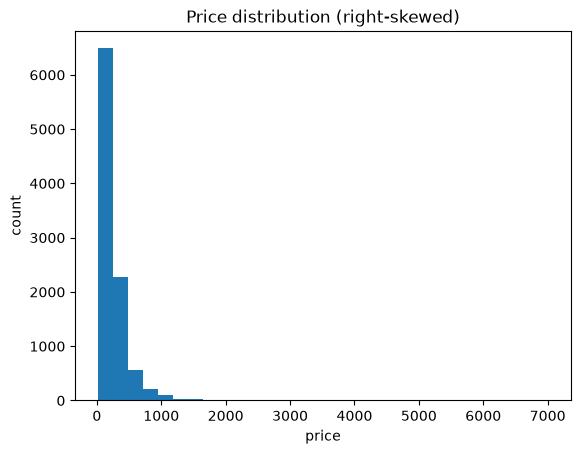

In [374]:
plt.hist(df['price'], bins=30)
plt.xlabel('price')
plt.ylabel('count')
plt.title('Price distribution (right-skewed)')
plt.show()
#Note data is skewwed right

Train Test Spilt

In [375]:
from sklearn.model_selection import train_test_split

price_bins = pd.qcut(df['price'], q=10, labels=False, duplicates='drop')
traindf, testdf = train_test_split(df, test_size=0.2, stratify=price_bins)

traindf = traindf.copy()
testdf = testdf.copy()

print(f"Train size: {len(traindf)}, Test size: {len(testdf)}")

Train size: 7802, Test size: 1951


Remove Price Outliers on train bounds

In [376]:
q1 = traindf['price'].quantile(0.25)
q3 = traindf['price'].quantile(0.9)
iqr = q3 - q1
lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

print(f"Price bounds (from train only): [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Train rows dropped: {((traindf['price'] < lower_bound) | (traindf['price'] > upper_bound)).sum()}")
print(f"Test rows dropped:  {((testdf['price'] < lower_bound) | (testdf['price'] > upper_bound)).sum()}")

traindf = traindf[(traindf['price'] >= lower_bound) & (traindf['price'] <= upper_bound)]
testdf = testdf[(testdf['price'] >= lower_bound) & (testdf['price'] <= upper_bound)]

print(f"Train size: {len(traindf)}, Test size: {len(testdf)}")

Price bounds (from train only): [0.00, 1052.90]
Train rows dropped: 126
Test rows dropped:  35
Train size: 7676, Test size: 1916


Missingness patterns

In [377]:
missingness_cols = ['bedrooms', 'bathrooms']

for col in missingness_cols:
    is_missing = traindf[col].isna()
    pct_missing = is_missing.mean() * 100
    price_missing = traindf.loc[is_missing, 'price'].mean()
    price_present = traindf.loc[~is_missing, 'price'].mean()
    print(f"{col:>22}: {pct_missing:5.1f}% missing | "
          f"avg price when missing = {price_missing:7.2f} | avg price when present = {price_present:7.2f}")

              bedrooms:  40.6% missing | avg price when missing =  162.17 | avg price when present =  271.27
             bathrooms:  11.2% missing | avg price when missing =  216.95 | avg price when present =  228.23


In [378]:
for col in missingness_cols:
    traindf[f'{col}_missing'] = traindf[col].isna().astype(int)
    testdf[f'{col}_missing'] = testdf[col].isna().astype(int)

Impute bedrooms and bathrooms

In [379]:
bedroom_medians = traindf.groupby('accommodates')['bedrooms'].median()
bathroom_medians = traindf.groupby('accommodates')['bathrooms'].median()

for splitdf in (traindf, testdf):
    splitdf['bedrooms'] = splitdf['bedrooms'].fillna(splitdf['accommodates'].map(bedroom_medians))
    splitdf['bathrooms'] = splitdf['bathrooms'].fillna(splitdf['accommodates'].map(bathroom_medians))


Bedroom/bathroom Ratios(Measuring Crampedness)

In [380]:
traindf['bedroom/accommodates'] = traindf['bedrooms'] / traindf['accommodates']
traindf['bathroom/accommodates'] = traindf['bathrooms'] / traindf['accommodates'] 

testdf['bedroom/accommodates'] = testdf['bedrooms'] / testdf['accommodates'] 
testdf['bathroom/accommodates'] = testdf['bathrooms'] / testdf['accommodates'] 

How Busy The AirBnb is

In [381]:
traindf['bookedness'] = traindf['availability_60'] - 2 * traindf['reviews_per_month']
testdf['bookedness'] = testdf['availability_60'] - 2 * testdf['reviews_per_month']

Property Type OneHotEncoding

In [382]:
traindummies = pd.get_dummies(traindf['property_type'], prefix='property type', drop_first=True, dtype=int)
testdummies = pd.get_dummies(testdf['property_type'], prefix='property type', drop_first=True, dtype=int)
testdummies = testdummies.reindex(columns=traindummies.columns, fill_value=0)

Amenities Encoding

In [383]:
mlb = MultiLabelBinarizer()
amenitiestrain = pd.DataFrame(
    mlb.fit_transform(traindf['amenitiesclean']),
    columns=list(mlb.classes_), index=traindf.index
)
amenitiestest = pd.DataFrame(
    mlb.transform(testdf['amenitiesclean']),
    columns=list(mlb.classes_), index=testdf.index
)

# Safety net: force identical columns/order between train and test
amenitiestest = amenitiestest.reindex(columns=amenitiestrain.columns, fill_value=0)

amenitiestrain['n_amenities'] = amenitiestrain.sum(axis=1)
amenitiestest['n_amenities'] = amenitiestest.sum(axis=1)

c:\Users\aypen\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py:1016: UserWarning: unknown class(es) [' Samsung stainless steel single oven', '120 inch HDTV with Apple TV, HBO Max, Netflix, Amazon Prime Video', '23 inch HDTV', '24 inch HDTV with Hulu, Netflix', '27 inch HDTV', '30 inch HDTV with Amazon Prime Video, Fire TV, Netflix', '30 inch HDTV with HBO Max', '30 inch TV with Chromecast, Roku', '32 inch HDTV with Amazon Prime Video, Apple TV, Disney+, HBO Max, Hulu, Netflix, Roku', '32 inch HDTV with Amazon Prime Video, Hulu, Disney+, Netflix', '32 inch HDTV with Amazon Prime Video, Roku', '32 inch HDTV with Chromecast', '32 inch HDTV with Chromecast, standard cable, Netflix, Hulu, HBO Max, Disney+', '32 inch HDTV with Netflix, Amazon Prime Video', '32 inch HDTV with premium cable, Roku', '32 inch HDTV with standard cable, Netflix, Roku', '32 inch TV with Amazon Prime Video, Fire TV', '32 inch TV with Amazon Prime Video, Fire TV, Disney+, Net

In [384]:
traindf['n_amenities'] = amenitiestrain['n_amenities']
testdf['n_amenities'] = amenitiestest['n_amenities']

Kmeans Clustering to represent neighborhoods

Text(0, 0.5, 'latitude')

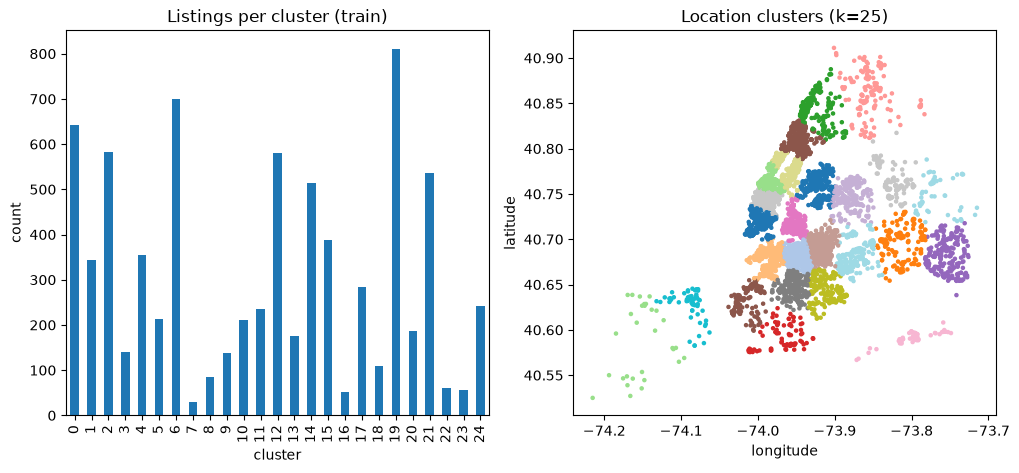

In [385]:
from sklearn.cluster import KMeans

clusters = 25

kmeans = KMeans(n_clusters=clusters, n_init=15)
kmeans.fit(traindf[['latitude', 'longitude']])

traindf['locationcluster'] = kmeans.predict(traindf[['latitude', 'longitude']])
testdf['locationcluster'] = kmeans.predict(testdf[['latitude', 'longitude']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

traindf['locationcluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Listings per cluster (train)')
axes[0].set_xlabel('cluster')
axes[0].set_ylabel('count')

scatter = axes[1].scatter(traindf['longitude'], traindf['latitude'],
                           c=traindf['locationcluster'], cmap='tab20', s=5)
axes[1].set_title(f'Location clusters (k={clusters})')
axes[1].set_xlabel('longitude')
axes[1].set_ylabel('latitude')

In [386]:
loctraindummies = pd.get_dummies(traindf['locationcluster'], prefix='location cluster', drop_first=True, dtype=int)
loctestdummies = pd.get_dummies(testdf['locationcluster'], prefix='location cluster', drop_first=True, dtype=int)
loctestdummies = loctestdummies.reindex(columns=loctraindummies.columns, fill_value=0)


Final train/test features

In [387]:
base_cols = ['price', 'accommodates', 'bedroom/accommodates', 'bathroom/accommodates', 
             'review_scores_rating', 'reviews_per_month', 'availability_60', 'bedrooms',
             'latitude', 'longitude', 'n_amenities', 'hosts_time_as_host', 'bookedness',
             'bathrooms']

trainfinal = pd.concat([
    traindf[base_cols].reset_index(drop=True),
    traindummies.reset_index(drop=True),
    loctraindummies.reset_index(drop=True),
], axis=1).dropna().drop_duplicates()

testfinal = pd.concat([
    testdf[base_cols].reset_index(drop=True),
    testdummies.reset_index(drop=True),
    loctestdummies.reset_index(drop=True),
], axis=1).dropna()

Xtrain = trainfinal.drop(columns=['price'])
ytrain = trainfinal['price']
Xtest = testfinal.drop(columns=['price']).reindex(columns=Xtrain.columns, fill_value=0)
ytest = testfinal['price']

print(f"X_train: {Xtrain.shape}   X_test: {Xtest.shape}")

X_train: (7521, 84)   X_test: (1875, 84)


In [388]:
import optuna
import xgboost as xgb
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import log_loss
from sklearn.metrics import root_mean_squared_error

In [389]:
def objective(trial):
    params = {
        "objective": "reg:squarederror",   # or "reg:absoluteerror", "reg:pseudohubererror" for robustness to outliers
        "eval_metric": "rmse",
        "booster": "gbtree",
        "tree_method": "hist",
        "verbosity": 0,
        
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(Xtrain)):
        X_tr, X_val = Xtrain.iloc[train_idx], Xtrain.iloc[valid_idx]
        y_tr, y_val = ytrain.iloc[train_idx], ytrain.iloc[valid_idx]

        model = TransformedTargetRegressor(
            regressor=xgb.XGBRegressor(**params),
            func=np.log1p,
            inverse_func=np.expm1,
        )
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, pred)
        scores.append(rmse)

        # report running mean so far, keyed by fold index
        trial.report(np.mean(scores), step=fold_idx)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
study.optimize(objective, n_trials=100, timeout=3600)
print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-09-04 18:39:37,718] A new study created in memory with name: no-name-679fd7a0-d456-4802-a376-e5c54228b8b5
[I 2026-09-04 18:39:40,304] Trial 0 finished with value: 132.09064759007333 and parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.008476394367391726, 'subsample': 0.6664605844010156, 'colsample_bytree': 0.7961584995806936, 'min_child_weight': 13, 'gamma': 4.833945289864306, 'reg_alpha': 0.004626305948636582, 'reg_lambda': 1.6658247962037633}. Best is trial 0 with value: 132.09064759007333.
[I 2026-09-04 18:39:49,966] Trial 1 finished with value: 118.22677667452993 and parameters: {'n_estimators': 850, 'max_depth': 9, 'learning_rate': 0.004406724020209205, 'subsample': 0.616075938023109, 'colsample_bytree': 0.6059763169119238, 'min_child_weight': 10, 'gamma': 2.7982598669865903, 'reg_alpha': 2.1478545145993886, 'reg_lambda': 5.896056845307712e-05}. Best is trial 1 with value: 118.22677667452993.
[I 2026-09-04 18:39:54,301] Trial 2 finished with value: 107.

Best params: {'n_estimators': 650, 'max_depth': 10, 'learning_rate': 0.054813651051018396, 'subsample': 0.8618946630836847, 'colsample_bytree': 0.6804478229701209, 'min_child_weight': 17, 'gamma': 0.04108052114939857, 'reg_alpha': 0.18734507035413817, 'reg_lambda': 3.469151954333786e-07}
Best RMSE: 99.46066968765284


In [390]:
best_model = xgb.XGBRegressor(**study.best_params)
best_model.fit(Xtrain, ytrain)

trainr2 = best_model.score(Xtrain, ytrain)
testr2 = best_model.score(Xtest, ytest)

trainrmse = root_mean_squared_error(ytrain, best_model.predict(Xtrain))
testrmse = root_mean_squared_error(ytest, best_model.predict(Xtest))

print(f"Train R²: {trainr2:.4f}   Test R²: {testr2:.4f}")
print(f"Train RMSE: {trainrmse:.2f}   Test RMSE: {testrmse:.2f}")


Train R²: 0.9795   Test R²: 0.6672
Train RMSE: 24.88   Test RMSE: 101.39


In [391]:
mdi_importances = best_model.feature_importances_

# Format into a clean DataFrame
features_df = pd.DataFrame({
    'Feature': Xtest.columns.tolist(),
    'Importance': mdi_importances
}).sort_values(by='Importance', ascending=False)

print(features_df)

                                     Feature  Importance
0                               accommodates    0.142633
6                                   bedrooms    0.111981
12                                 bathrooms    0.101714
50               property type_Room in hotel    0.057142
42      property type_Private room in resort    0.038370
..                                       ...         ...
52  property type_Shared room in guest suite    0.000000
58        property type_Shared room in villa    0.000000
57    property type_Shared room in townhouse    0.000000
59                   property type_Tiny home    0.000000
54         property type_Shared room in home    0.000000

[84 rows x 2 columns]


In [392]:
features_df[features_df['Importance'] > 0].head(10)

,Feature,Importance
0,accommodates,0.142633
6,bedrooms,0.111981
12,bathrooms,0.101714
50,property type_Room in hotel,0.057142
42,property type_Private room in resort,0.038370
65,location cluster_6,0.035885
41,property type_Private room in rental unit,0.035454
2,bathroom/accommodates,0.025002
8,longitude,0.024084
48,property type_Room in aparthotel,0.023451
